# Cluster analysis: averaged comparison of uniform and patch sequences

This notebook shows two representative analyses used to compare condensate structure across sequence patterns.

For each condition, we average over the five final snapshots

- `final_state_Run1.DATA`
- `final_state_Run2.DATA`
- `final_state_Run3.DATA`
- `final_state_Run4.DATA`
- `final_state_Run5.DATA`

from the following folders:

- `Dispersed_initCond/run_uniform/Ens_0.30_Es_6.00`
- `Dispersed_initCond/run_patch/Ens_0.30_Es_6.00`

We will generate:

1. an averaged intermolecular sticker-sticker distance histogram comparing uniform and patchy sequences on the same plot,
2. averaged cluster-size distributions shown separately for uniform and patchy sequences.

This notebook is intended as a brief worked example. Additional data-analysis helpers are documented on the CASPULE website.

In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist
from collections import defaultdict, Counter, deque

font = {
    "family": "arial",
    "size": 16,
}
plt.rc("font", **font)

# ---- paths ----
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    REPO_ROOT = ROOT.parent
else:
    REPO_ROOT = ROOT

UNIFORM_DIR = REPO_ROOT / "Dispersed_initCond" / "run_uniform" / "Ens_0.30_Es_6.00"
PATCH_DIR   = REPO_ROOT / "Dispersed_initCond" / "run_patch"   / "Ens_0.30_Es_6.00"

RUNS = range(1, 6)
FILE_NAME = "final_state_Run{}.DATA"

print("Repo root:   ", REPO_ROOT)
print("Uniform dir: ", UNIFORM_DIR)
print("Patch dir:   ", PATCH_DIR)

Repo root:    /Users/davidkanovich/GitHub/StickerPatterning
Uniform dir:  /Users/davidkanovich/GitHub/StickerPatterning/Dispersed_initCond/run_uniform/Ens_0.30_Es_6.00
Patch dir:    /Users/davidkanovich/GitHub/StickerPatterning/Dispersed_initCond/run_patch/Ens_0.30_Es_6.00


## Notes on averaging

The CASPULE analysis helpers are designed primarily for single-snapshot analysis. Here we apply the same per-snapshot logic to each of the five final snapshots for a condition, then average the resulting distributions across runs.

This produces a cleaner comparison between sequence patterns and more closely matches the way manuscript figures are generated.

In [2]:
SECTION_END = {
    "velocities", "bonds", "angles", "dihedrals",
    "impropers", "masses", "pair", "angle",
    "dihedral", "improper"
}

def find_atoms_start(lines):
    """
    Return index of first line after the 'Atoms' header block.
    Handles either:
      Atoms
      Atoms # full
    followed by optional blank line.
    """
    for i, line in enumerate(lines):
        s = line.strip().lower()
        if s.startswith("atoms"):
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            return j
    return None


def parse_type13_atoms(path: Path):
    """
    Parse atom section and return:
      mol_ids: molecule ids for atom types 1 and 3
      coords:  xyz for atom types 1 and 3
    """
    with open(path, "r") as fh:
        lines = fh.readlines()

    start = find_atoms_start(lines)
    if start is None:
        return None, None

    mols = []
    xyz = []

    for line in lines[start:]:
        s = line.strip()
        if not s:
            continue
        sl = s.lower()
        if any(sl.startswith(k) for k in SECTION_END):
            break
        if s.startswith("#"):
            continue

        parts = s.split()
        if len(parts) < 7:
            continue

        atom_type = int(parts[2])
        if atom_type in (1, 3):
            mols.append(int(parts[1]))
            xyz.append(tuple(map(float, parts[4:7])))

    if len(mols) < 2:
        return None, None

    return np.array(mols, dtype=int), np.asarray(xyz, dtype=float)


def condensed_mask_diff_mol(mol_ids: np.ndarray):
    iu = np.triu_indices(mol_ids.size, k=1)
    return mol_ids[iu[0]] != mol_ids[iu[1]]


def parse_bonds_for_clusters(path: Path):
    """
    Parse Bonds section and return connected components over molecule IDs.

    Logic:
    - map atom_id -> molecule_id from Atoms section
    - read bond pairs from Bonds section
    - if a bond connects atoms belonging to different molecules, that implies
      those molecules belong to the same cluster
    - connected components over molecule IDs define clusters
    """
    with open(path, "r") as fh:
        lines = fh.readlines()

    # ---- atom_id -> molecule_id map ----
    atoms_start = find_atoms_start(lines)
    if atoms_start is None:
        raise ValueError(f"Could not locate Atoms section in {path}")

    atom_to_mol = {}
    all_mols = set()

    i = atoms_start
    while i < len(lines):
        s = lines[i].strip()
        if not s:
            i += 1
            continue
        sl = s.lower()
        if any(sl.startswith(k) for k in SECTION_END):
            break
        if s.startswith("#"):
            i += 1
            continue

        parts = s.split()
        if len(parts) >= 2:
            atom_id = int(parts[0])
            mol_id  = int(parts[1])
            atom_to_mol[atom_id] = mol_id
            all_mols.add(mol_id)
        i += 1

    # ---- find Bonds section ----
    bonds_start = None
    for j, line in enumerate(lines):
        if line.strip().lower().startswith("bonds"):
            bonds_start = j + 1
            while bonds_start < len(lines) and not lines[bonds_start].strip():
                bonds_start += 1
            break

    # no bonds section -> all molecules are monomers
    if bonds_start is None:
        return [1] * len(all_mols)

    graph = defaultdict(set)

    # initialize graph with all molecules present
    for m in all_mols:
        graph[m]

    for line in lines[bonds_start:]:
        s = line.strip()
        if not s:
            continue
        sl = s.lower()
        if any(sl.startswith(k) for k in {"angles", "dihedrals", "impropers", "velocities", "pair", "angle", "dihedral", "improper"}):
            break
        if s.startswith("#"):
            continue

        parts = s.split()
        if len(parts) < 4:
            continue

        atom1 = int(parts[2])
        atom2 = int(parts[3])

        mol1 = atom_to_mol.get(atom1)
        mol2 = atom_to_mol.get(atom2)

        if mol1 is None or mol2 is None:
            continue

        if mol1 != mol2:
            graph[mol1].add(mol2)
            graph[mol2].add(mol1)

    # connected components over molecule graph
    visited = set()
    cluster_sizes = []

    for m in graph:
        if m in visited:
            continue

        q = deque([m])
        visited.add(m)
        comp = []

        while q:
            u = q.popleft()
            comp.append(u)
            for v in graph[u]:
                if v not in visited:
                    visited.add(v)
                    q.append(v)

        cluster_sizes.append(len(comp))

    return cluster_sizes

In [4]:
def average_sticker_distance_hist(folder: Path, bin_w=0.2, max_r=1000.0):
    nbins = int(np.ceil(max_r / bin_w))
    bins = np.linspace(0.0, nbins * bin_w, nbins + 1)
    centers = 0.5 * (bins[:-1] + bins[1:])

    total_hist = np.zeros(nbins, dtype=float)
    used = 0

    for run in RUNS:
        fp = folder / FILE_NAME.format(run)
        if not fp.exists():
            print(f"Missing: {fp}")
            continue

        mols, coords = parse_type13_atoms(fp)
        if mols is None:
            print(f"Skipped {fp.name}: <2 type-1/3 atoms")
            continue

        mask = condensed_mask_diff_mol(mols)
        if not mask.any():
            print(f"Skipped {fp.name}: no intermolecular type-1/3 pairs")
            continue

        dists = pdist(coords)[mask]
        hist, _ = np.histogram(dists, bins=bins)
        total_hist += hist
        used += 1

    if used == 0:
        raise RuntimeError(f"No usable runs found in {folder}")

    avg_hist = total_hist / used
    return centers, avg_hist, used

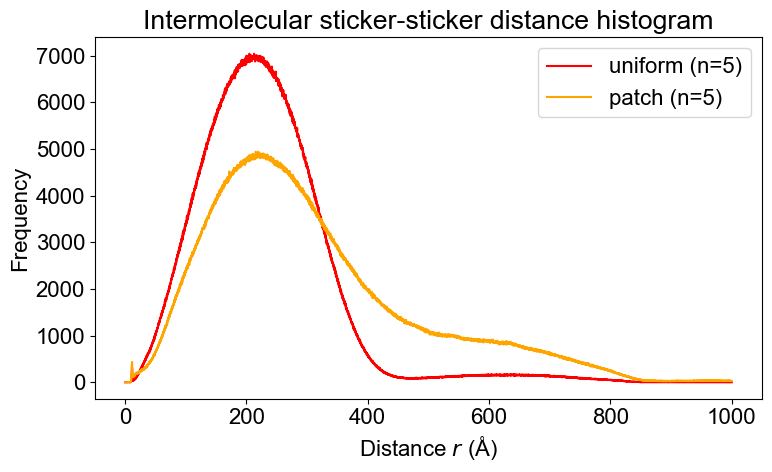

In [5]:
r_uniform, h_uniform, n_uniform = average_sticker_distance_hist(UNIFORM_DIR)
r_patch,   h_patch,   n_patch   = average_sticker_distance_hist(PATCH_DIR)

plt.figure(figsize=(8, 5))
plt.plot(r_uniform, h_uniform, drawstyle="steps-mid", color="red",    label=f"uniform (n={n_uniform})")
plt.plot(r_patch,   h_patch,   drawstyle="steps-mid", color="orange", label=f"patch (n={n_patch})")

plt.xlabel(r"Distance $r$ (Å)")
plt.ylabel("Frequency")
plt.title("Intermolecular sticker-sticker distance histogram")
plt.legend()
plt.tight_layout()
plt.show()

The plot above compares the averaged intermolecular sticker-sticker distance distributions for uniform and patch sequences. Each curve is the average of the five final snapshots for that condition.

In [ ]:
def cluster_distribution_single_snapshot(path: Path):
    """
    Return the chain-weighted cluster-size distribution for one snapshot.

    If a snapshot contains clusters of sizes:
      [1, 1, 2, 5]
    then the total number of chains is 1+1+2+5 = 9, and the chain-weighted
    probabilities are:
      P(1) = 2/9
      P(2) = 2/9
      P(5) = 5/9
    """
    cluster_sizes = parse_bonds_for_clusters(path)
    total_chains = sum(cluster_sizes)

    counts = Counter()
    for s in cluster_sizes:
        counts[s] += s  # chain-weighted

    sizes = np.array(sorted(counts.keys()), dtype=int)
    probs = np.array([counts[s] / total_chains for s in sizes], dtype=float)
    return sizes, probs


def average_cluster_distribution(folder: Path):
    size_to_values = defaultdict(list)
    used = 0

    for run in RUNS:
        fp = folder / FILE_NAME.format(run)
        if not fp.exists():
            print(f"Missing: {fp}")
            continue

        sizes, probs = cluster_distribution_single_snapshot(fp)
        for s, p in zip(sizes, probs):
            size_to_values[int(s)].append(float(p))
        used += 1

    if used == 0:
        raise RuntimeError(f"No usable runs found in {folder}")

    all_sizes = np.array(sorted(size_to_values.keys()), dtype=int)
    mean_probs = np.array([np.mean(size_to_values[s]) for s in all_sizes], dtype=float)
    std_probs  = np.array([np.std(size_to_values[s])  for s in all_sizes], dtype=float)

    return all_sizes, mean_probs, std_probs, used

In [7]:
sizes_u, probs_u, std_u, n_u = average_cluster_distribution(UNIFORM_DIR)
sizes_p, probs_p, std_p, n_p = average_cluster_distribution(PATCH_DIR)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

axes[0].bar(sizes_u, probs_u, color="red", alpha=0.9)
axes[0].set_title(f"Uniform (avg over {n_u} runs)")
axes[0].set_xlabel("Cluster size")
axes[0].set_ylabel("Fraction of chains")

axes[1].bar(sizes_p, probs_p, color="orange", alpha=0.9)
axes[1].set_title(f"Patch (avg over {n_p} runs)")
axes[1].set_xlabel("Cluster size")

for ax in axes:
    ax.set_xlim(left=0)

plt.tight_layout()
plt.show()

NameError: name 'average_cluster_distribution' is not defined

The two panels above show averaged chain-weighted cluster-size distributions for the uniform and patch conditions.

This notebook includes only two representative examples. Additional data-analysis scripts and usage examples are available in the CASPULE documentation.